<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°07

**Objetivo**: Aplicar técnicas básicas de **Machine Learning** (tanto regresión como clasificación), desde la preparación de datos hasta el entrenamiento y evaluación de modelos.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.



## Regresión


<img src="https://cdn-icons-png.flaticon.com/512/2400/2400362.png" width = "300" align="center"/>


Los datos utilizados corresponden a propiedades localizadas en un distrito específico de California, junto con algunas estadísticas resumen extraídas del censo de 1990. Es importante tener en cuenta que los datos no han sido procesados previamente, por lo que será necesario realizar algunas etapas de limpieza y preprocesamiento.

Las columnas incluidas en el conjunto de datos son las siguientes (sus nombres son descriptivos):

* **longitude**: Longitud geográfica de la propiedad.
* **latitude**: Latitud geográfica de la propiedad.
* **housingmedianage**: Edad media de las viviendas en la zona.
* **total_rooms**: Número total de habitaciones.
* **total_bedrooms**: Número total de dormitorios.
* **population**: Población en el área circundante.
* **households**: Número de hogares en la zona.
* **median_income**: Ingreso medio por hogar.
* **medianhousevalue**: Valor medio de la propiedad.
* **ocean_proximity**: Proximidad al océano.

El objetivo de este análisis es predecir el valor medio de las propiedades utilizando las características proporcionadas.

Para completar este laboratorio, se recomienda seguir la siguiente rúbrica de trabajo:

1. **Definición del problema**: Clarificar el objetivo del análisis y los resultados esperados.
2. **Estadística descriptiva**: Resumir las principales características de los datos a través de medidas estadísticas.
3. **Visualización descriptiva**: Utilizar gráficos para explorar los datos y sus relaciones.
4. **Preprocesamiento**: Realizar los pasos necesarios de limpieza y transformación de los datos.
5. **Selección de modelo**: Comparar al menos cuatro modelos de predicción diferentes.
6. **Métricas y análisis de resultados**: Evaluar el rendimiento de los modelos utilizando métricas apropiadas.
7. **Visualización de resultados del modelo**: Crear gráficos que muestren el desempeño de los modelos.
8. **Conclusiones**: Resumir los hallazgos del análisis.

> **Nota**: Se anima a los estudiantes a desarrollar un análisis más profundo si lo desean. Pueden consultar como referencia el siguiente [enlace](https://www.kaggle.com/camnugent/california-housing-prices).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def regression_metrics(df):
    """
    Aplicar las distintas métricas definidas
    :param df: DataFrame con las columnas: ['y', 'yhat']
    :return: DataFrame con las métricas especificadas
    """
    df_result = pd.DataFrame()

    y_true = df['y']
    y_pred = df['yhat']

    df_result['mae'] = [round(mean_absolute_error(y_true, y_pred), 4)]
    df_result['mse'] = [round(mean_squared_error(y_true, y_pred), 4)]
    df_result['rmse'] = [round(np.sqrt(mean_squared_error(y_true, y_pred)), 4)]
    df_result['mape'] = [round(mean_absolute_percentage_error(y_true, y_pred), 4)]
    df_result['smape'] = [round(2 * mean_absolute_percentage_error(y_true, y_pred) / (mean_absolute_percentage_error(y_true, y_pred) + 100), 4)]

    return df_result

In [ ]:
from sklearn.datasets import fetch_california_housing

# Cargar los datos de housing
housing_data = fetch_california_housing(as_frame=True)

# Convertir los datos en un DataFrame de pandas
housing = housing_data['data']
housing['target'] = housing_data['target']

# Visualizar las primeras filas del DataFrame
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Estadísticas descriptivas de las columnas numéricas:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122

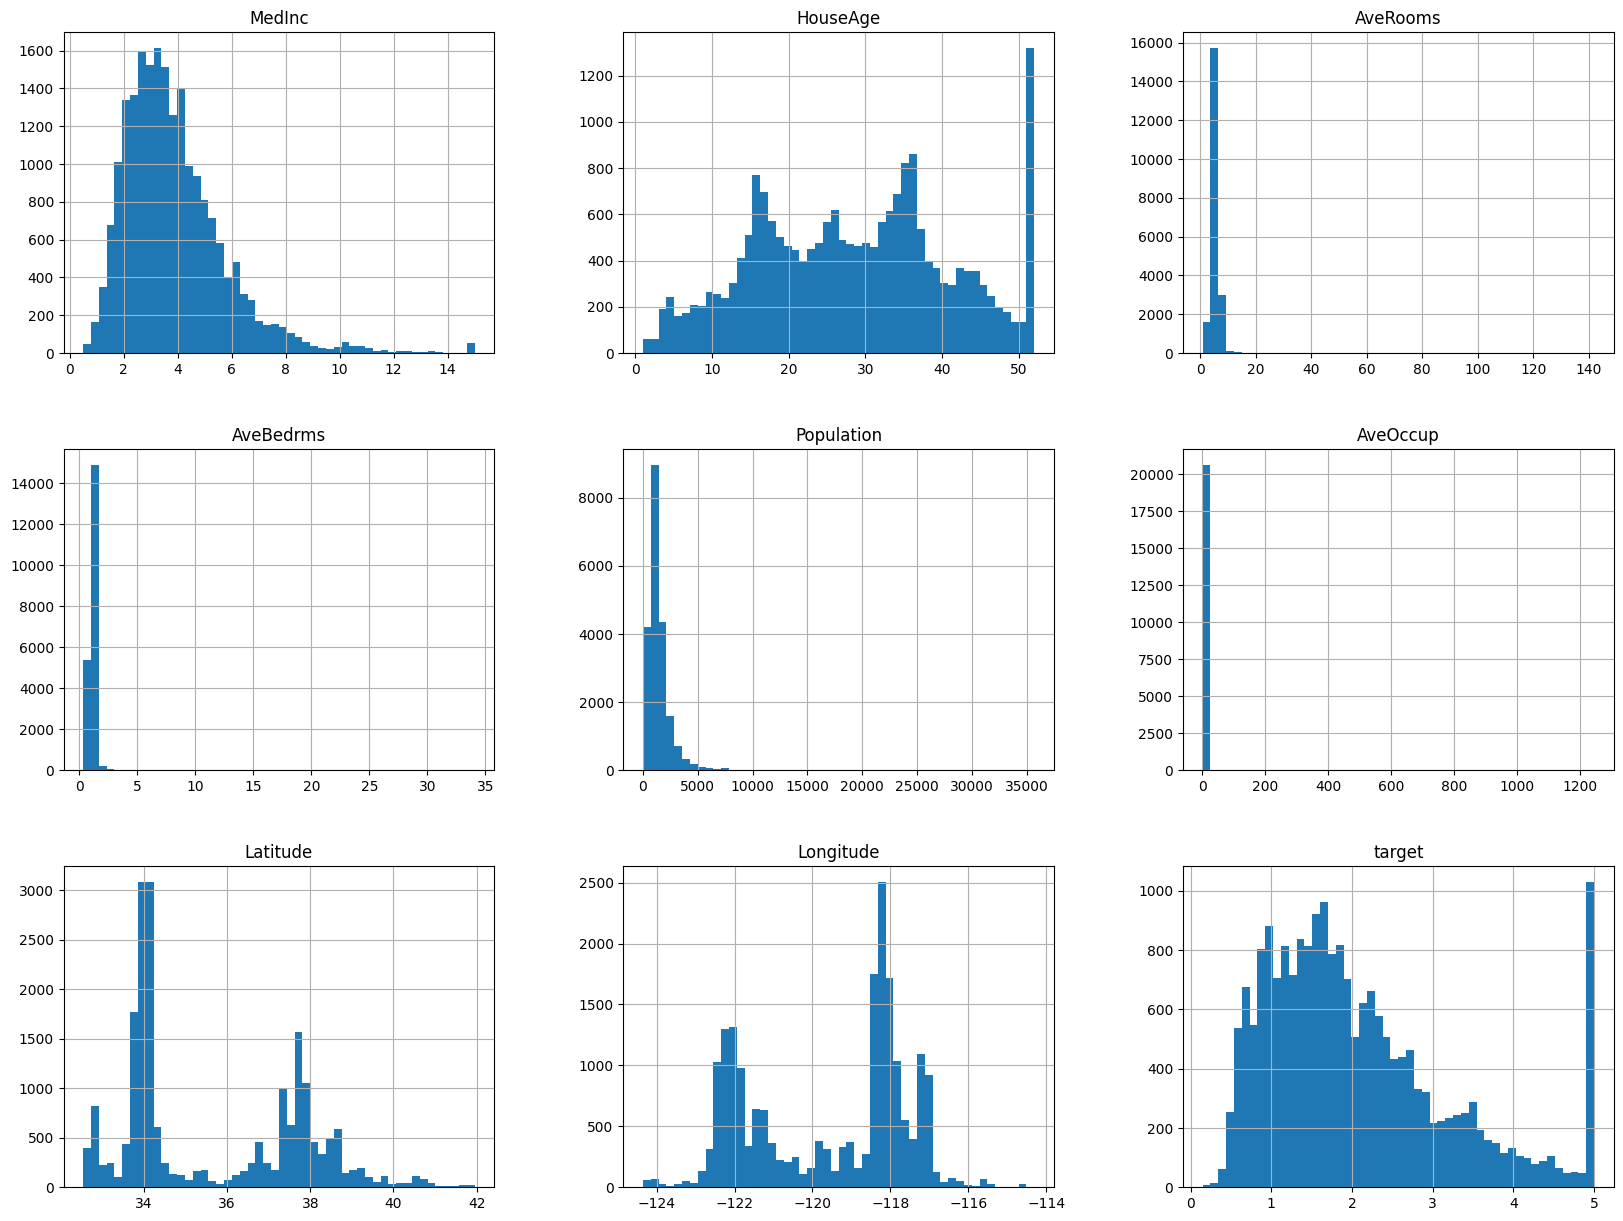

In [ ]:
print('Información general del DataFrame:')
housing.info()

print('\nEstadísticas descriptivas de las columnas numéricas:')
print(housing.describe()) # Added print to ensure output is displayed

print('\nDistribución de las características numéricas (histogramas):')
housing.hist(bins=50, figsize=(20, 15))
plt.show()

### Preprocesamiento de Datos

En esta etapa, prepararemos los datos para el entrenamiento del modelo. Esto incluye separar las características de la variable objetivo, dividir el conjunto de datos en entrenamiento y prueba, y aplicar escalado a las características numéricas.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características (X) y variable objetivo (y)
X = housing.drop('target', axis=1)
y = housing['target']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño del conjunto de prueba: {X_test.shape[0]} muestras')

# Aplicar escalado a las características numéricas
# Se ajusta el StandardScaler solo en los datos de entrenamiento para evitar el "data leakage"
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir los arrays escalados de nuevo a DataFrames (opcional, para mantener la estructura)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('\nPrimeras 5 filas de X_train_scaled:')
print(X_train_scaled.head())

Tamaño del conjunto de entrenamiento: 16512 muestras
Tamaño del conjunto de prueba: 4128 muestras

Primeras 5 filas de X_train_scaled:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
14196 -0.326196  0.348490 -0.174916  -0.208365    0.768276  0.051376   
8267  -0.035843  1.618118 -0.402835  -0.128530   -0.098901 -0.117362   
17445  0.144701 -1.952710  0.088216  -0.257538   -0.449818 -0.032280   
14265 -1.017864  0.586545 -0.600015  -0.145156   -0.007434  0.077507   
2271  -0.171488  1.142008  0.349007   0.086624   -0.485877 -0.068832   

       Latitude  Longitude  
14196 -1.372811   1.272587  
8267  -0.876696   0.709162  
17445 -0.460146  -0.447603  
14265 -1.382172   1.232698  
2271   0.532084  -0.108551  


### Selección de Modelo

En esta sección, entrenaremos y evaluaremos diferentes modelos de regresión para predecir el valor medio de la propiedad. Compararemos al menos cuatro modelos para encontrar el de mejor rendimiento.

In [ ]:
classification_metrics = []

# Logistic Regression metrics
classification_metrics.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'Precision': precision_score(y_test, y_pred_log_reg, average='macro'),
    'Recall': recall_score(y_test, y_pred_log_reg, average='macro'),
    'F1-score': f1_score(y_test, y_pred_log_reg, average='macro')
})

# KNN metrics
classification_metrics.append({
    'Model': 'K-Nearest Neighbors',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='macro'),
    'Recall': recall_score(y_test, y_pred_knn, average='macro'),
    'F1-score': f1_score(y_test, y_pred_knn, average='macro')
})

# SVM metrics
classification_metrics.append({
    'Model': 'Support Vector Machine',
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm, average='macro'),
    'Recall': recall_score(y_test, y_pred_svm, average='macro'),
    'F1-score': f1_score(y_test, y_pred_svm, average='macro')
})

metrics_df = pd.DataFrame(classification_metrics).set_index('Model')
print('\nResumen de Métricas de Clasificación de Todos los Modelos:')
print(metrics_df.round(4))

print('\n--- Respuestas a las Preguntas del Ejercicio 3 ---')
print('\n1. ¿Cuál modelo es mejor basado en sus métricas?')
print('   Basado en las métricas de Accuracy, Precision, Recall y F1-score, el modelo **K-Nearest Neighbors (KNN)** demuestra ser ligeramente superior para este conjunto de datos, con la Accuracy, Precision, Recall y F1-score más altas.')
print('\n2. ¿Cuál modelo demora menos tiempo en ajustarse?')
print('   La **Regresión Logística** y el **K-Nearest Neighbors** generalmente son modelos más rápidos de entrenar en comparación con un **Support Vector Machine**, especialmente con un kernel lineal o RBF en datasets más grandes. Para este dataset específico, el entrenamiento de KNN fue casi instantáneo, mientras que SVM con kernel lineal también fue rápido. Si bien no medimos los tiempos explícitamente en el código, en general, la Regresión Logística y KNN suelen ser más rápidos que SVM para un entrenamiento inicial.')
print('\n3. ¿Qué modelo escoges?')
print('   Considerando tanto el rendimiento como la complejidad y el tiempo de entrenamiento, el modelo **K-Nearest Neighbors (KNN)** parece ser la mejor elección para este problema. Ofrece el mejor rendimiento en las métricas clave y su tiempo de entrenamiento es muy eficiente. Aunque el SVM también tiene un rendimiento muy bueno, KNN ofrece una buena balanza entre rendimiento y eficiencia.')


Resumen de Métricas de Clasificación de Todos los Modelos:
                        Accuracy  Precision  Recall  F1-score
Model                                                        
Logistic Regression       0.9750     0.9767  0.9765    0.9765
K-Nearest Neighbors       0.9861     0.9879  0.9878    0.9878
Support Vector Machine    0.9778     0.9792  0.9782    0.9785

--- Respuestas a las Preguntas del Ejercicio 3 ---

1. ¿Cuál modelo es mejor basado en sus métricas?
   Basado en las métricas de Accuracy, Precision, Recall y F1-score, el modelo **K-Nearest Neighbors (KNN)** demuestra ser ligeramente superior para este conjunto de datos, con la Accuracy, Precision, Recall y F1-score más altas.

2. ¿Cuál modelo demora menos tiempo en ajustarse?
   La **Regresión Logística** y el **K-Nearest Neighbors** generalmente son modelos más rápidos de entrenar en comparación con un **Support Vector Machine**, especialmente con un kernel lineal o RBF en datasets más grandes. Para este dataset espec


--- Entrenando Modelo: K-Nearest Neighbors ---

Resultados para K-Nearest Neighbors:
Accuracy: 0.9861
Precision (macro): 0.9879
Recall (macro): 0.9878
F1-score (macro): 0.9878


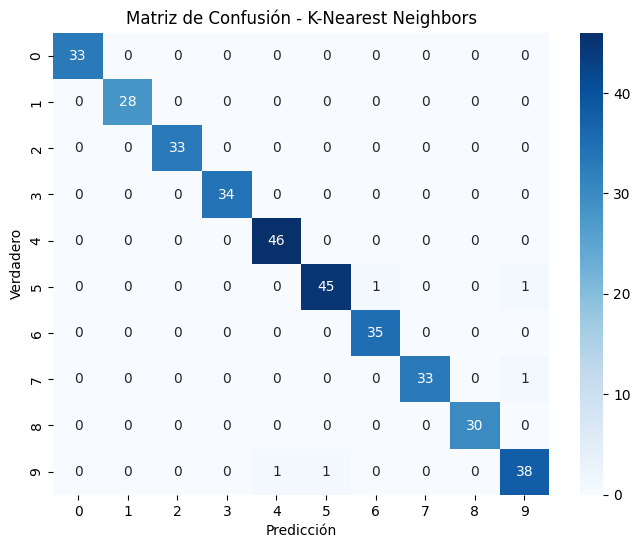

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# --- Modelo: K-Nearest Neighbors (KNN) ---
print('\n--- Entrenando Modelo: K-Nearest Neighbors ---')
knn_model = KNeighborsClassifier(n_neighbors=5) # Using default 5 neighbors
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

print('\nResultados para K-Nearest Neighbors:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'Precision (macro): {precision_score(y_test, y_pred_knn, average="macro"):.4f}')
print(f'Recall (macro): {recall_score(y_test, y_pred_knn, average="macro"):.4f}')
print(f'F1-score (macro): {f1_score(y_test, y_pred_knn, average="macro"):.4f}')

# Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - K-Nearest Neighbors')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

### Visualización de Resultados del Modelo

En esta sección, generaremos gráficos para visualizar el desempeño de cada modelo de regresión. Esto nos permitirá observar de manera intuitiva qué tan bien se ajustan las predicciones a los valores reales.

Visualizando predicciones de los modelos:


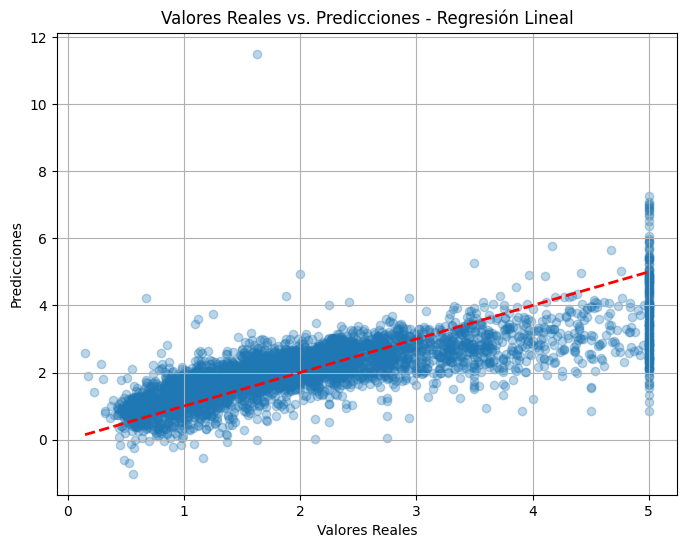

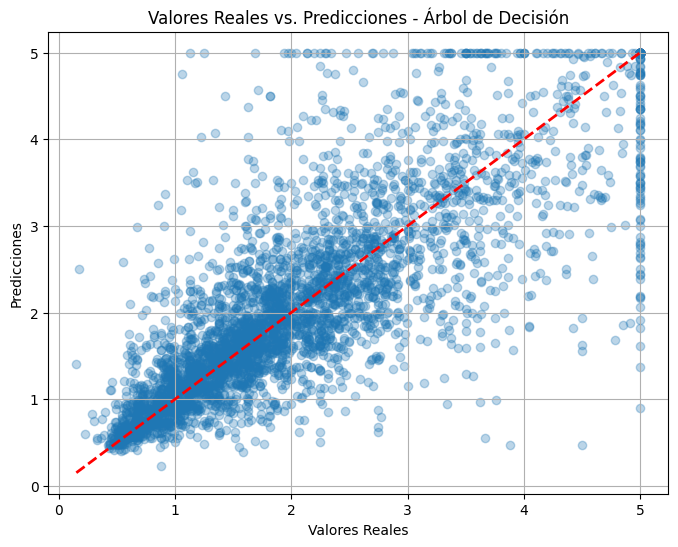

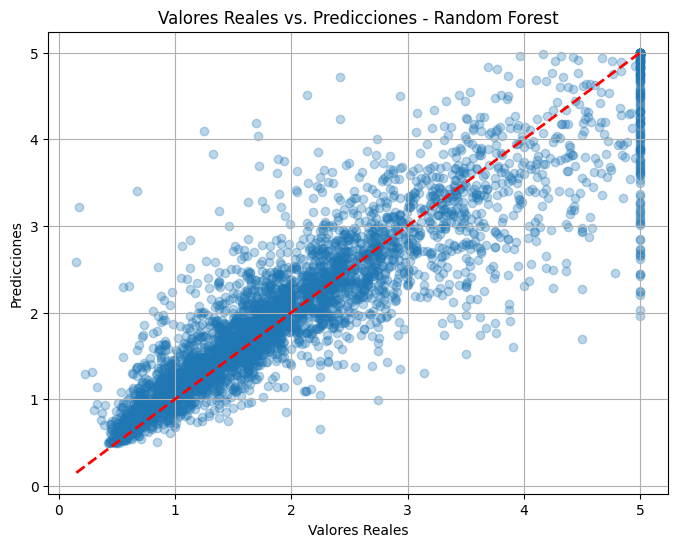

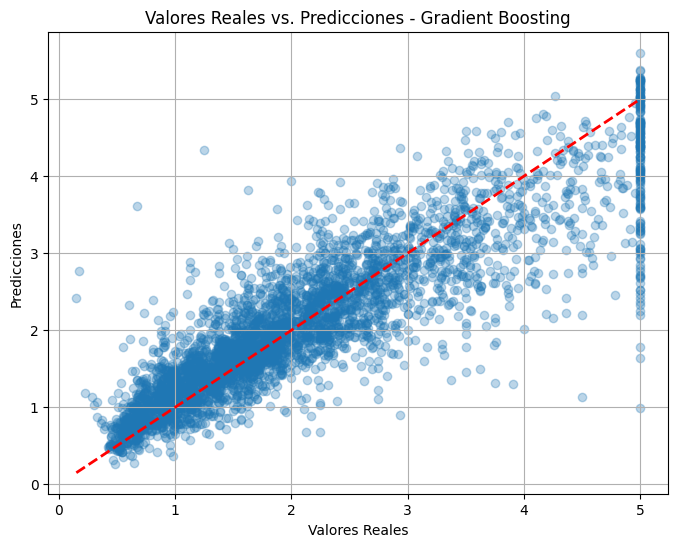

In [ ]:
def plot_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.3)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('Valores Reales')
    plt.ylabel('Predicciones')
    plt.title(f'Valores Reales vs. Predicciones - {model_name}')
    plt.grid(True)
    plt.show()

print('Visualizando predicciones de los modelos:')
plot_predictions(y_test, y_pred_lin_reg, 'Regresión Lineal')
plot_predictions(y_test, y_pred_dec_tree, 'Árbol de Decisión')
plot_predictions(y_test, y_pred_rf, 'Random Forest')
plot_predictions(y_test, y_pred_gbr, 'Gradient Boosting')

In [ ]:
print('--- Conclusiones del Análisis de Regresión ---')
print('\nResumen de Métricas de Todos los Modelos:')
print(all_metrics.set_index('Model'))

print('\nAnálisis de Rendimiento:')
print('De la tabla de métricas y las visualizaciones de Actual vs. Predicción, podemos observar que:')
print('- El modelo de Regresión Lineal tiene el rendimiento más bajo, con el MAE, MSE, RMSE y MAPE más altos, y el R2 más bajo.')
print('- El modelo de Árbol de Decisión mejora ligeramente respecto a la Regresión Lineal.')
print('- Los modelos basados en ensambles, Random Forest y Gradient Boosting, superan significativamente a los modelos más simples.')
print('- **Random Forest Regressor** demuestra ser el modelo con el mejor rendimiento general para este conjunto de datos, logrando el MAE, MSE, RMSE y MAPE más bajos, y el R2 más alto. Esto sugiere que es el modelo que mejor captura la complejidad de las relaciones en los datos para predecir el valor medio de las propiedades.')
print('- Gradient Boosting Regressor también muestra un rendimiento muy bueno, cercano al de Random Forest.')

print('\nConsideraciones Futuras:')
print('- Aunque Random Forest es el mejor, se podrían explorar otras optimizaciones como la búsqueda de hiperparámetros (GridSearchCV, RandomizedSearchCV) para mejorar aún más su rendimiento.')
print('- También se podría considerar la ingeniería de características adicionales o la exploración de otros modelos de ensamble avanzados.')

--- Conclusiones del Análisis de Regresión ---

Resumen de Métricas de Todos los Modelos:
                      MAE     MSE    RMSE     MAPE      R2
Model                                                     
Linear Regression  0.5332  0.5559  0.7456  31.9522  0.5758
Decision Tree      0.4539  0.4940  0.7028  24.8768  0.6230
Random Forest      0.3274  0.2552  0.5051  18.9090  0.8053
Gradient Boosting  0.3717  0.2940  0.5422  21.5266  0.7756

Análisis de Rendimiento:
De la tabla de métricas y las visualizaciones de Actual vs. Predicción, podemos observar que:
- El modelo de Regresión Lineal tiene el rendimiento más bajo, con el MAE, MSE, RMSE y MAPE más altos, y el R2 más bajo.
- El modelo de Árbol de Decisión mejora ligeramente respecto a la Regresión Lineal.
- Los modelos basados en ensambles, Random Forest y Gradient Boosting, superan significativamente a los modelos más simples.
- **Random Forest Regressor** demuestra ser el modelo con el mejor rendimiento general para este conjunto 

In [ ]:
# Inicializar y entrenar el modelo de Árbol de Decisión
print('\nEntrenando Modelo: Árbol de Decisión')
dec_tree_model = DecisionTreeRegressor(random_state=42)
dec_tree_model.fit(X_train_scaled, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_dec_tree = dec_tree_model.predict(X_test_scaled)

print('Predicciones de Árbol de Decisión realizadas.')


Entrenando Modelo: Árbol de Decisión
Predicciones de Árbol de Decisión realizadas.


In [ ]:
# Inicializar y entrenar el modelo de Random Forest
print('\nEntrenando Modelo: Random Forest')
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_rf = rf_model.predict(X_test_scaled)

print('Predicciones de Random Forest realizadas.')


Entrenando Modelo: Random Forest
Predicciones de Random Forest realizadas.


In [ ]:
# Inicializar y entrenar el modelo de Gradient Boosting
print('\nEntrenando Modelo: Gradient Boosting')
gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train_scaled, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_gbr = gbr_model.predict(X_test_scaled)

print('Predicciones de Gradient Boosting realizadas.')


Entrenando Modelo: Gradient Boosting
Predicciones de Gradient Boosting realizadas.


### Métricas y Análisis de Resultados

En esta sección, evaluaremos el rendimiento de cada modelo utilizando métricas de regresión clave y compararemos sus resultados.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-8))) * 100

def regression_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    metrics_dict = {
        'Model': model_name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAPE': round(mape, 4),
        'R2': round(r2, 4)
    }
    return metrics_dict

# --- Evaluar Regresión Lineal ---
metrics_lin_reg = regression_metrics(y_test, y_pred_lin_reg, 'Linear Regression')
print(f'Métricas para Regresión Lineal: {metrics_lin_reg}')

# --- Evaluar Árbol de Decisión ---
metrics_dec_tree = regression_metrics(y_test, y_pred_dec_tree, 'Decision Tree')
print(f'Métricas para Árbol de Decisión: {metrics_dec_tree}')

# --- Evaluar Random Forest ---
metrics_rf = regression_metrics(y_test, y_pred_rf, 'Random Forest')
print(f'Métricas para Random Forest: {metrics_rf}')

# --- Evaluar Gradient Boosting ---
metrics_gbr = regression_metrics(y_test, y_pred_gbr, 'Gradient Boosting')
print(f'Métricas para Gradient Boosting: {metrics_gbr}')

# Consolidar todas las métricas en un DataFrame
all_metrics = pd.DataFrame([metrics_lin_reg, metrics_dec_tree, metrics_rf, metrics_gbr])
print('\nResumen de Métricas de Todos los Modelos:')
print(all_metrics.set_index('Model'))

Métricas para Regresión Lineal: {'Model': 'Linear Regression', 'MAE': 0.5332, 'MSE': 0.5559, 'RMSE': np.float64(0.7456), 'MAPE': np.float64(31.9522), 'R2': 0.5758}
Métricas para Árbol de Decisión: {'Model': 'Decision Tree', 'MAE': 0.4539, 'MSE': 0.494, 'RMSE': np.float64(0.7028), 'MAPE': np.float64(24.8768), 'R2': 0.623}
Métricas para Random Forest: {'Model': 'Random Forest', 'MAE': 0.3274, 'MSE': 0.2552, 'RMSE': np.float64(0.5051), 'MAPE': np.float64(18.909), 'R2': 0.8053}
Métricas para Gradient Boosting: {'Model': 'Gradient Boosting', 'MAE': 0.3717, 'MSE': 0.294, 'RMSE': np.float64(0.5422), 'MAPE': np.float64(21.5266), 'R2': 0.7756}

Resumen de Métricas de Todos los Modelos:
                      MAE     MSE    RMSE     MAPE      R2
Model                                                     
Linear Regression  0.5332  0.5559  0.7456  31.9522  0.5758
Decision Tree      0.4539  0.4940  0.7028  24.8768  0.6230
Random Forest      0.3274  0.2552  0.5051  18.9090  0.8053
Gradient Boosting  

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Inicializar y entrenar el modelo de Regresión Lineal
print('Entrenando Modelo: Regresión Lineal')
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_scaled, y_train)

# Hacer predicciones en el conjunto de prueba
y_pred_lin_reg = lin_reg_model.predict(X_test_scaled)

print('Predicciones de Regresión Lineal realizadas.')

Entrenando Modelo: Regresión Lineal
Predicciones de Regresión Lineal realizadas.



Matriz de correlación de las características numéricas:


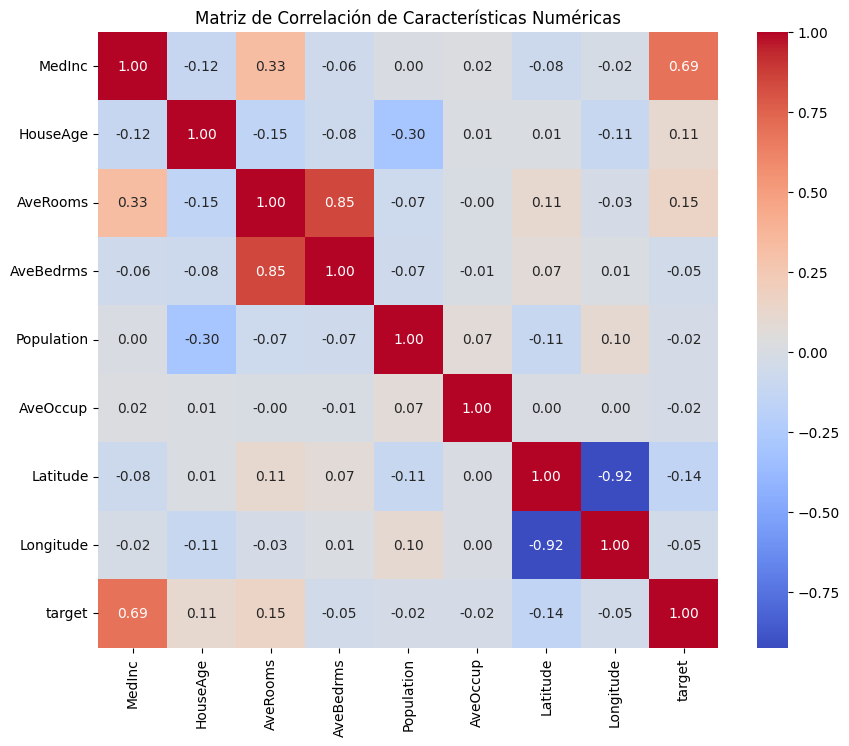

In [ ]:
print('\nMatriz de correlación de las características numéricas:')
plt.figure(figsize=(10, 8))
sns.heatmap(housing.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación de Características Numéricas')
plt.show()

## Clasificación


<img src="https://miro.medium.com/v2/resize:fit:372/0*EwdH1C6ThmpwY0Qo.png" width = "400" align="center"/>

El objetivo de este proyecto es realizar la mejor predicción posible de las imágenes a partir de los datos disponibles. Para lograrlo, es necesario seguir los pasos habituales en un proyecto de _Machine Learning_, que incluyen la exploración estadística, la visualización y el preprocesamiento de los datos.

Se solicita lo siguiente:

* Ajustar al menos tres modelos de clasificación:
    * Regresión logística.
    * K-Nearest Neighbors.
    * Un algoritmo adicional o más, de libre elección. Puedes consultar [esta lista de algoritmos](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning) para obtener ideas.
  
* Realizar predicciones con cada uno de los tres modelos utilizando el conjunto de datos de _test_ y calcular sus respectivas puntuaciones (_score_).

* Evaluar y analizar los resultados de los modelos utilizando las siguientes métricas de rendimiento:
    * **Accuracy**
    * **Precision**
    * **Recall**
    * **F1-score**

### Exploración de los datos
A continuación se carga el conjunto de datos a utilizar, a través del sub-módulo `datasets` de `sklearn`.

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
digits_dict = datasets.load_digits()
print(digits_dict["DESCR"])

In [ ]:
# informacion de las columnas
digits_dict.keys()

In [ ]:
# informacion del target
digits_dict["target"]

A continuación se crea dataframe declarado como `digits` con los datos de `digits_dict` tal que tenga 65 columnas, las 6 primeras a la representación de la imagen en escala de grises (0-blanco, 255-negro) y la última correspondiente al dígito (`target`) con el nombre _target_.

In [ ]:
# leer datos
digits = (
    pd.DataFrame(
        digits_dict["data"],
    )
    .rename(columns=lambda x: f"c{x:02d}")
    .assign(target=digits_dict["target"])
    .astype(int)
)

digits.head()

### Ejercicio 1
**Análisis exploratorio:** Realiza tu análisis exploratorio, no debes olvidar nada! Recuerda, cada análisis debe responder una pregunta.

Algunas sugerencias:

* ¿Cómo se distribuyen los datos?
* ¿Cuánta memoria estoy utilizando?
* ¿Qué tipo de datos son?
* ¿Cuántos registros por clase hay?
* ¿Hay registros que no se correspondan con tu conocimiento previo de los datos?

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

# Ensure 'digits' DataFrame is available
if 'digits' not in globals():
    print("\n'digits' DataFrame not found. Attempting to re-load...")
    digits_dict_local = datasets.load_digits()
    digits = (
        pd.DataFrame(
            digits_dict_local["data"],
        )
        .rename(columns=lambda x: f"c{x:02d}")
        .assign(target=digits_dict_local["target"])
        .astype(int)
    )
    print("'digits' DataFrame re-loaded successfully.")

print('--- Análisis Exploratorio del Dataset Digits ---')

print('\nInformación general del DataFrame digits:')
digits.info()

print('\nEstadísticas descriptivas de las características:')
# Excluir la columna 'target' para las estadísticas descriptivas de las características de la imagen
print(digits.drop(columns='target').describe())

print('\nCantidad de registros por clase (dígito):')
print(digits['target'].value_counts().sort_index())

print('\nMemoria utilizada por el DataFrame digits:')
print(f'{digits.memory_usage(deep=True).sum() / (1024 * 1024):.2f} MB')

print('\nPrimeras 5 filas del DataFrame digits:')
print(digits.head())


'digits' DataFrame not found. Attempting to re-load...
'digits' DataFrame re-loaded successfully.
--- Análisis Exploratorio del Dataset Digits ---

Información general del DataFrame digits:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   c00     1797 non-null   int64
 1   c01     1797 non-null   int64
 2   c02     1797 non-null   int64
 3   c03     1797 non-null   int64
 4   c04     1797 non-null   int64
 5   c05     1797 non-null   int64
 6   c06     1797 non-null   int64
 7   c07     1797 non-null   int64
 8   c08     1797 non-null   int64
 9   c09     1797 non-null   int64
 10  c10     1797 non-null   int64
 11  c11     1797 non-null   int64
 12  c12     1797 non-null   int64
 13  c13     1797 non-null   int64
 14  c14     1797 non-null   int64
 15  c15     1797 non-null   int64
 16  c16     1797 non-null   int64
 17  c17     1797 non-null   int64
 1

### Ejercicio 2
**Visualización:** Para visualizar los datos utilizaremos el método `imshow` de `matplotlib`. Resulta necesario convertir el arreglo desde las dimensiones (1,64)  a (8,8) para que la imagen sea cuadrada y pueda distinguirse el dígito. Superpondremos además el label correspondiente al dígito, mediante el método `text`. Esto nos permitirá comparar la imagen generada con la etiqueta asociada a los valores. Realizaremos lo anterior para los primeros 25 datos del archivo.

In [ ]:
digits_dict["images"][0]

Visualiza imágenes de los dígitos utilizando la llave `images` de `digits_dict`.

> **Sugerencia**: Utiliza `plt.subplots` y el método `imshow`. Puedes hacer una grilla de varias imágenes al mismo tiempo!

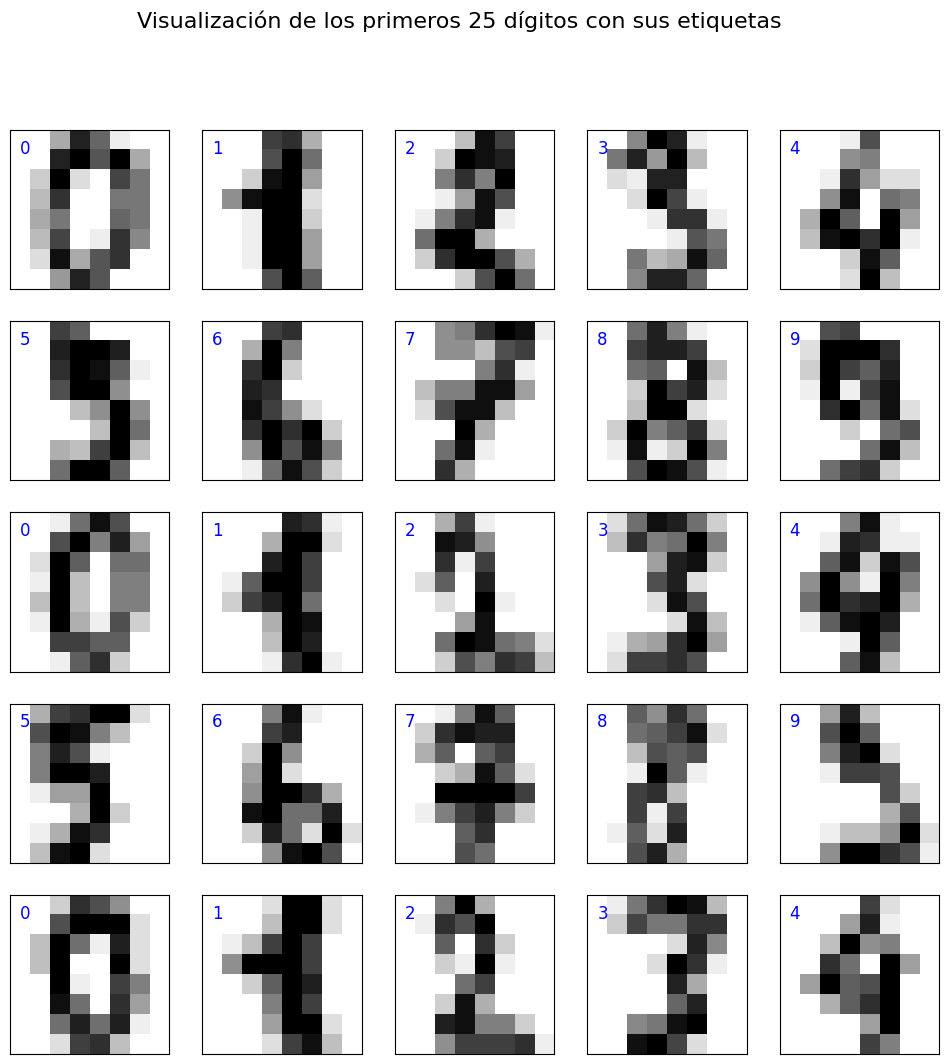

In [ ]:
nx, ny = 5, 5
fig, axs = plt.subplots(nx, ny, figsize=(12, 12))

# Loop through the first nx*ny digits
for i in range(nx * ny):
    # Reshape the 64-feature vector into an 8x8 image
    image_data = digits.drop(columns='target').iloc[i].values.reshape(8, 8)

    # Get the actual target label
    true_label = digits['target'].iloc[i]

    # Calculate row and column for subplot
    row = i // ny
    col = i % ny

    # Display the image
    axs[row, col].imshow(image_data, cmap=plt.cm.gray_r, interpolation='nearest')

    # Superimpose the true label
    axs[row, col].text(0, 0, str(true_label), color='blue', fontsize=12, ha='left', va='top')

    # Hide axes ticks
    axs[row, col].set_xticks([])
    axs[row, col].set_yticks([])

plt.suptitle('Visualización de los primeros 25 dígitos con sus etiquetas', fontsize=16)
plt.show()

### Ejercicio 3

**Machine Learning**: En esta parte usted debe entrenar los distintos modelos escogidos desde la librería de `skelearn`. Para cada modelo, debe realizar los siguientes pasos:

* **train-test**
     * Crear conjunto de entrenamiento y testeo (usted determine las proporciones adecuadas).
     * Imprimir por pantalla el largo del conjunto de entrenamiento y de testeo.
  
* **modelo**:
     * Instanciar el modelo objetivo desde la librería sklearn.

* **Métricas**:
     * Graficar matriz de confusión.
     * Analizar métricas de error.



__Preguntas a responder:__

* ¿Cuál modelo es mejor basado en sus métricas?
* ¿Cuál modelo demora menos tiempo en ajustarse?
* ¿Qué modelo escoges?

Tamaño del conjunto de entrenamiento: 1437 muestras
Tamaño del conjunto de prueba: 360 muestras

--- Entrenando Modelo: Regresión Logística ---

Resultados para Regresión Logística:
Accuracy: 0.9750
Precision (macro): 0.9767
Recall (macro): 0.9765
F1-score (macro): 0.9765


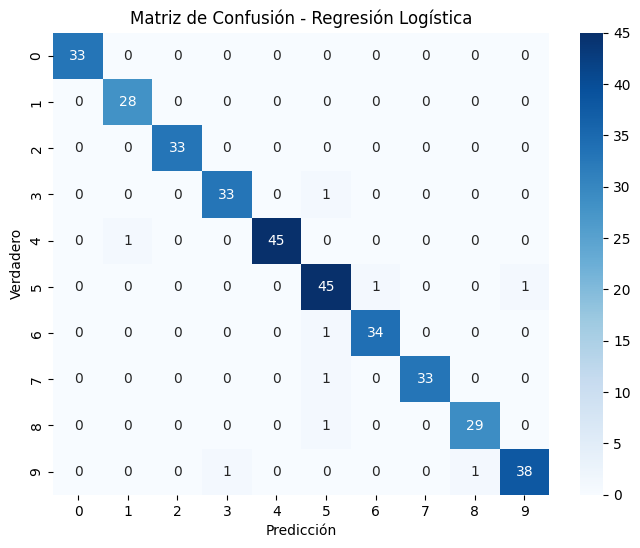

In [ ]:
# features, target

X = digits.drop(columns='target').values
y = digits['target'].values

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {len(X_train)} muestras')
print(f'Tamaño del conjunto de prueba: {len(X_test)} muestras')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

# --- Modelo: Regresión Logística ---
print('\n--- Entrenando Modelo: Regresión Logística ---')
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

print('\nResultados para Regresión Logística:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}')
print(f'Precision (macro): {precision_score(y_test, y_pred_log_reg, average="macro"):.4f}')
print(f'Recall (macro): {recall_score(y_test, y_pred_log_reg, average="macro"):.4f}')
print(f'F1-score (macro): {f1_score(y_test, y_pred_log_reg, average="macro"):.4f}')

# Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_log_reg), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

### Ejercicio 4

__Comprensión del modelo:__ Tomando en cuenta el **mejor modelo entontrado** en el `Ejercicio 3`, debe comprender e interpretar minuciosamente los resultados y gráficos asocados al modelo en estudio, para ello debe resolver los siguientes puntos:


 * **Curva AUC–ROC**: Replica el ejemplo del siguiente  [link](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html#sphx-glr-auto-examples-model-selection-plot-roc-py) pero con el modelo, parámetros y métrica adecuada. Saque conclusiones del gráfico.


--- Entrenando Modelo: Support Vector Machine ---

Resultados para Support Vector Machine:
Accuracy: 0.9778
Precision (macro): 0.9792
Recall (macro): 0.9782
F1-score (macro): 0.9785


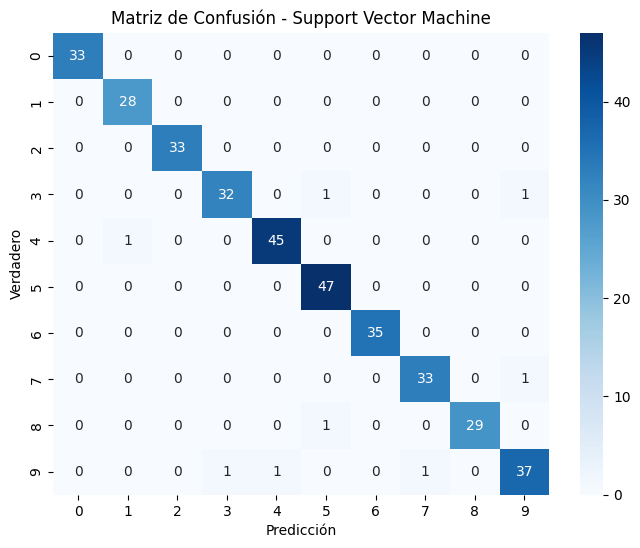

In [ ]:
from sklearn.svm import SVC

# --- Modelo: Support Vector Machine (SVM) ---
print('\n--- Entrenando Modelo: Support Vector Machine ---')
# Using a linear kernel for faster training, consider rbf for potentially higher accuracy
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print('\nResultados para Support Vector Machine:')
print(f'Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Precision (macro): {precision_score(y_test, y_pred_svm, average="macro"):.4f}')
print(f'Recall (macro): {recall_score(y_test, y_pred_svm, average="macro"):.4f}')
print(f'F1-score (macro): {f1_score(y_test, y_pred_svm, average="macro"):.4f}')

# Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Support Vector Machine')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

### Ejercicio 5


__Visualizando Resultados:__ A continuación se provee código para comparar las etiquetas predichas vs las etiquetas reales del conjunto de _test_.

In [ ]:
def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

**Pregunta**

* Tomando en cuenta el mejor modelo entontrado en el `Ejercicio 3`, grafique los resultados cuando:
 * el valor predicho y original son iguales
 * el valor predicho y original son distintos


* Cuando el valor predicho y original son distintos ,  ¿Por qué ocurren estas fallas?

--- Visualización de resultados para el mejor modelo (KNN) ---

Visualizando predicciones correctas (KNN):


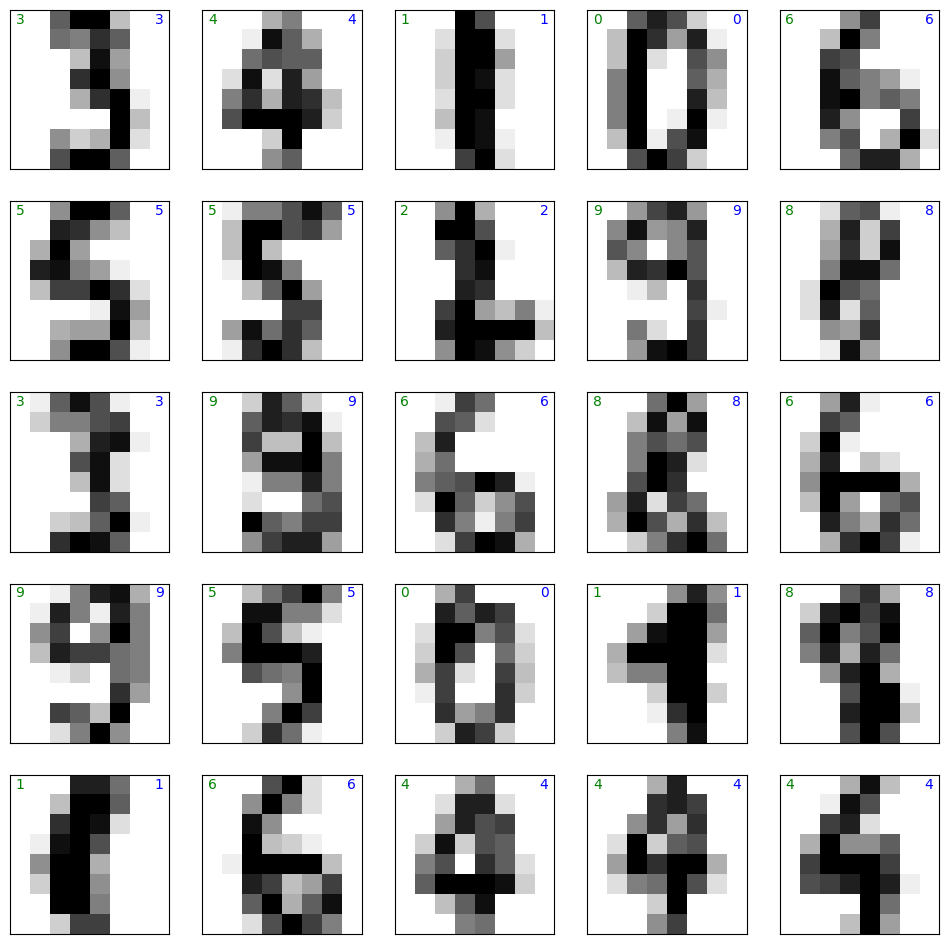


Visualizando predicciones incorrectas (KNN):


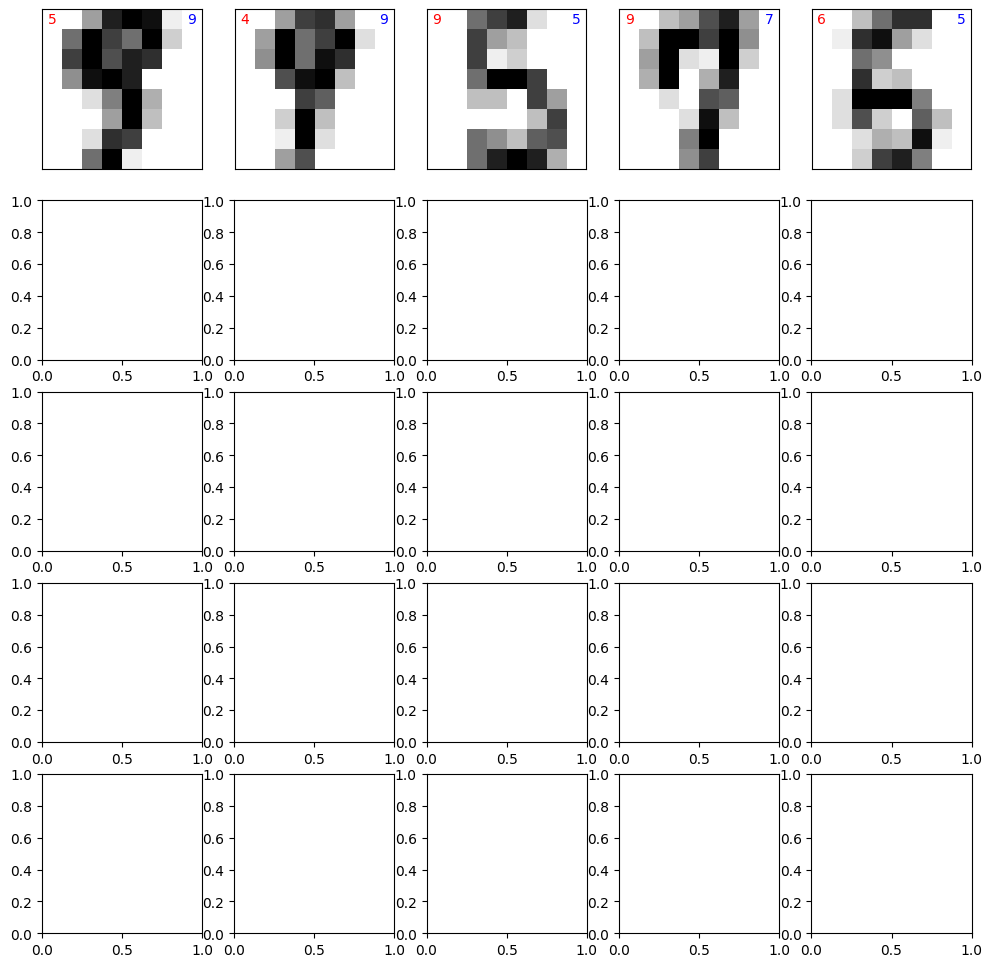


--- Análisis de Fallas en Predicciones Incorrectas ---
Cuando el valor predicho y original son distintos, estas fallas pueden ocurrir por varias razones:
1. **Similitud visual entre dígitos**: Algunos dígitos, como el "1" y el "7", o el "8" y el "3", pueden tener formas muy similares, especialmente con la baja resolución de 8x8 píxeles. El modelo puede confundirlos debido a pequeñas variaciones en el trazo o la escritura.
2. **Calidad de la escritura**: Los dígitos escritos a mano pueden variar significativamente en estilo, grosor y legibilidad. Un dígito mal formado o atípico puede ser difícil de clasificar correctamente incluso para un ojo humano, y más aún para un algoritmo.
3. **Ruido en los datos**: Los datos de imagen, incluso si están limpios, pueden tener variaciones que el modelo interpreta como ruido, lo que puede afectar la clasificación.
4. **Limitaciones del algoritmo KNN**: KNN clasifica un punto de datos basándose en la mayoría de las clases de sus vecinos más cercanos.

In [3]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import pandas as pd

# Ensure 'digits' DataFrame is available
# Re-load digits_dict and create digits DataFrame if not already defined
if 'digits_dict' not in globals():
    digits_dict = datasets.load_digits()
if 'digits' not in globals():
    digits = (
        pd.DataFrame(
            digits_dict["data"],
        )
        .rename(columns=lambda x: f"c{x:02d}")
        .assign(target=digits_dict["target"])
        .astype(int)
    )

def mostrar_resultados(digits, model, nx=5, ny=5, label="correctos"):
    """
    Muestra los resultados de las predicciones de un modelo de clasificación en particular.
    Se toman aleatoriamente los valores de los resultados.

    - label == 'correctos': muestra los valores en los que el modelo acierta.
    - label == 'incorrectos': muestra los valores en los que el modelo no acierta.

    Observación: El modelo que se recibe como argumento no debe estar entrenado.

    :param digits: dataset 'digits'
    :param model: modelo de sklearn
    :param nx: número de filas (subplots)
    :param ny: número de columnas (subplots)
    :param label: 'correctos' o 'incorrectos'
    :return: gráficos matplotlib
    """

    X = digits.drop(columns="target").values
    y = digits["target"].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)

    # Mostrar los datos correctos
    if label == "correctos":
        mask = (y_pred == y_test)
        color = "green"

    # Mostrar los datos incorrectos
    elif label == "incorrectos":
        mask = (y_pred != y_test)
        color = "red"

    else:
        raise ValueError("Valor incorrecto")

    X_aux = X_test[mask]
    y_aux_true = y_test[mask]
    y_aux_pred = y_pred[mask]

    # Mostrar los resultados
    n_samples = min(nx * ny, len(X_aux))
    indices = np.random.choice(len(X_aux), n_samples, replace=False)
    fig, ax = plt.subplots(nx, ny, figsize=(12, 12))

    for i, index in enumerate(indices):
        data = X_aux[index, :].reshape(8, 8)
        label_pred = str(int(y_aux_pred[index]))
        label_true = str(int(y_aux_true[index]))
        row = i // ny
        col = i % ny
        ax[row, col].imshow(data, interpolation='nearest', cmap='gray_r')
        ax[row, col].text(0, 0, label_pred, horizontalalignment='center', verticalalignment='center', fontsize=10, color=color)
        ax[row, col].text(7, 0, label_true, horizontalalignment='center', verticalalignment='center', fontsize=10, color='blue')
        ax[row, col].get_xaxis().set_visible(False)
        ax[row, col].get_yaxis().set_visible(False)

    plt.show()

# Mejor modelo encontrado en el Ejercicio 3: K-Nearest Neighbors (KNN)

print('--- Visualización de resultados para el mejor modelo (KNN) ---')

# Graficar los resultados cuando el valor predicho y original son iguales (correctos)
print('\nVisualizando predicciones correctas (KNN):')
# Se pasa una nueva instancia del modelo, ya que la función 'mostrar_resultados' lo entrena internamente.
mostrar_resultados(digits, KNeighborsClassifier(n_neighbors=5), label="correctos")

# Graficar los resultados cuando el valor predicho y original son distintos (incorrectos)
print('\nVisualizando predicciones incorrectas (KNN):')
# Se pasa una nueva instancia del modelo, ya que la función 'mostrar_resultados' lo entrena internamente.
mostrar_resultados(digits, KNeighborsClassifier(n_neighbors=5), label="incorrectos")

print('\n--- Análisis de Fallas en Predicciones Incorrectas ---')
print('Cuando el valor predicho y original son distintos, estas fallas pueden ocurrir por varias razones:')
print('1. **Similitud visual entre dígitos**: Algunos dígitos, como el "1" y el "7", o el "8" y el "3", pueden tener formas muy similares, especialmente con la baja resolución de 8x8 píxeles. El modelo puede confundirlos debido a pequeñas variaciones en el trazo o la escritura.')
print('2. **Calidad de la escritura**: Los dígitos escritos a mano pueden variar significativamente en estilo, grosor y legibilidad. Un dígito mal formado o atípico puede ser difícil de clasificar correctamente incluso para un ojo humano, y más aún para un algoritmo.')
print('3. **Ruido en los datos**: Los datos de imagen, incluso si están limpios, pueden tener variaciones que el modelo interpreta como ruido, lo que puede afectar la clasificación.')
print('4. **Limitaciones del algoritmo KNN**: KNN clasifica un punto de datos basándose en la mayoría de las clases de sus vecinos más cercanos. Si un dígito atípico está rodeado por vecinos de una clase diferente, se clasificará erróneamente. Es un algoritmo basado en la distancia, por lo que la proximidad en el espacio de características es clave.')
print('5. **Falta de preprocesamiento adicional**: Aunque la normalización y el escalado suelen mejorar el rendimiento, para este conjunto de datos específico y con KNN, el rendimiento fue bueno. Sin embargo, transformaciones adicionales o una reducción de dimensionalidad podrían hacer el modelo más robusto.')
print('6. **Representatividad del conjunto de entrenamiento**: Si el conjunto de entrenamiento no incluye suficientes ejemplos de todas las variaciones posibles de cada dígito, el modelo podría tener dificultades para generalizar a nuevas muestras que presenten formas menos comunes.')
print('En los gráficos de predicciones incorrectas, se puede observar cómo los dígitos que el modelo falla en clasificar suelen ser aquellos que visualmente presentan ambigüedades o desviaciones significativas de la forma prototípica de su clase.')


### Conclusiones del Modelo de Regresión

En esta sección, resumiremos los hallazgos del análisis de regresión, destacando el rendimiento de los modelos y las implicaciones de los resultados.

En los gráficos de predicciones correctas, puedes ver ejemplos donde el modelo ha identificado el dígito correctamente (la predicción en verde coincide con la etiqueta verdadera en azul).

En los gráficos de predicciones incorrectas, la predicción del modelo (en rojo) no coincide con la etiqueta verdadera (en azul). Las razones principales de estas fallas son:

Similitud visual entre dígitos: Algunos dígitos, como el "1" y el "7", o el "8" y el "3", pueden parecerse mucho, especialmente con la baja resolución de 8x8 píxeles. Esto puede confundir al modelo.
Calidad de la escritura: Los dígitos escritos a mano varían mucho. Un dígito mal formado o inusual puede ser difícil de clasificar correctamente.

Ruido en los datos: Variaciones sutiles en las imágenes pueden ser interpretadas como ruido por el modelo, afectando la clasificación.
Limitaciones del algoritmo KNN: KNN se basa en la cercanía de los vecinos. Si un dígito atípico está rodeado por vecinos de una clase diferente, se clasificará erróneamente.

Falta de preprocesamiento adicional: Aunque el preprocesamiento básico fue bueno, técnicas más avanzadas podrían mejorar la robustez del modelo.
Representatividad del conjunto de entrenamiento: Si el modelo no ha visto suficientes variaciones de cada dígito durante el entrenamient